# Datasets Preparation

In [1]:
verbose = False
%run ./2_0_datasets_preparation.ipynb

START DATASETS PREPARATION
verbose is False
>> imports
>> load trajectories
>> load bathymetry
>> load SWAN waterlevel
>> load wind
>> preprocessing bathymetry
resolution original dataset x~20.196657m and y~20.324707m
resolution downscaled x~100.982443m and y~101.623535m
>> preprocessing wind
>> defining misc shared methods
DONE DATASETS PREPARATION


# Parameters

In [6]:
trajectory_parameters = [[1,0.00],[2,0.00],[4,0.00],[8,0.00],[1,0.50],[1,0.75],[1,0.88]]# ds_intervals, ds_rnd_drop_fracts
grounding_directional_angle_per_step_deg = 58 #TODO value [86,84,82,77,72,57.6,84,82,77,72,57.6]
water_level_area_sampling_radius_meters = 250. # the local waterlevels are resampled at this distance and added to the plots to gve an impression of the reliability/stability of this sampling TODO add to global parameters?
grounding_timewindows_minutes = [180,90,45]
verbose = True
show_detailed_plots = False # long output
plots_output_root_dir = "plot/"

# 2: Grounding Detection

## Methods

In [ ]:
import matplotlib.pyplot as plt

def plot_timelines(tr, deived_timelines, statistics_parameters, file_label=None):
    i_dis, i_dir, st_dis, st_dir, st, sec_dis, sec_dir, sec, dir_change, hNAP, wl, wl_surroundings, wd, winding_numbers = deived_timelines
    grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step = statistics_parameters
    t_h = tr.t.values/(60*60) # times in hours
    N = t_h.shape[0]

    N_plots = 9
    fig, axs = plt.subplots(N_plots,figsize=(24,18))

    ip = 0
    for i in range(4):
      axs[ip].plot(t_h, wl_surroundings[i],c='cyan',linestyle="--",lw=0.5)
    axs[ip].plot(t_h,wl,c='blue')
    axs[ip].set_ylabel('waterlevel NAP [m]')

    ip += 1
    for i in range(4):
      wd_s = -(hNAP+wl_surroundings[i])
      axs[ip].plot(t_h, wd_s, c='cyan',linestyle="--",lw=0.5)
    axs[ip].plot(t_h, -hNAP,c='black',lw=0.5)
    axs[ip].plot(t_h, wd,c='blue')
    axs[ip].set_ylabel('waterdepth\nseabed level [m]')

    ip += 1
    axs[ip].plot(t_h,tr.v.values,c='red')
    axs[ip].set_ylabel('speed [m/s]')
    #ip += 1
    #axs[ip].plot(t_h,tr.ds.values,c='brown',label='distance m')
    #axs[ip].set_ylabel('displacement m')

    ip += 1
    axs[ip].plot(t_h,np.rad2deg(dir_change),c='green')
    axs[ip].set_ylabel('directional\nchange [deg]')
    axs[ip].set_yticks(np.linspace(-180,180,5))
    axs[ip].set_ylim([-180,180])

    ip += 1
    axs[ip].plot(t_h, i_dis,c='black')
    axs[ip].set_ylim([0,1])
    axs[ip].set_ylabel("$i_D []$")
    D_char = [grounding_displacement_caracteristic_distance, 108]
    for D in D_char:
      lvl = grounding_displacement_caracteristic_distance/(D+grounding_displacement_caracteristic_distance)
      axs[ip].plot(t_h, lvl*np.ones(N), c='red',linestyle="--",lw=0.5)

    ip += 1
    axs[ip].plot(t_h, i_dir,c='black')
    axs[ip].set_ylim([0,1])
    axs[ip].set_ylabel("$i_A []$")
    A_char = [grounding_directional_angle_per_step, np.deg2rad(58), np.deg2rad(90)]
    for A in A_char:
      lvl = A/(A+grounding_directional_angle_per_step)
      axs[ip].plot(t_h, lvl*np.ones(N), c='red',linestyle="--",lw=0.5)

    ip += 1
    rows = [[[sec_dir,"green"],[st_dir,"darkgreen"]],[[sec_dis,"red"],[st_dis,"darkred"]],[[sec,"grey"],[st,"black"]],[[tr["grounded"],"brown"]]]
    n_rows = len(rows)
    ones = np.ones(t_h.shape)
    for i in range(n_rows,0,-1):
      for line in rows[i-1]:
        vals, col = line
        axs[ip].fill_between(t_h, (i-1.)*vals, i*vals, where=vals>=0, color=col, step='mid')
      axs[ip].fill_between(t_h, 0, (i-1.)*ones, where=ones>=0, color='white', step='mid')
    axs[ip].set_ylim([0,n_rows])
    axs[ip].set_ylabel('thresholds []')

    ip += 1
    axs[ip].fill_between(t_h, 1.*tr.orientation, where=vals>=0, color='black', step='mid')
    axs[ip].set_ylim([0,1])
    axs[ip].set_ylabel('orientation []')

    ip += 1
    axs[ip].plot(t_h, np.cumsum(np.random.uniform(low=-np.pi, high=np.pi, size=t_h.shape[0])), c='black')
    axs[ip].plot(t_h, winding_numbers[:,0], c='green')
    axs[ip].plot(t_h, winding_numbers[:,1], c='lime')
    axs[ip].set_ylabel('cummulative\ndirection [deg]')

    for ip in range(N_plots):
      axs[ip].set_xlim([t_h[0],t_h[-1]])
      major_ticks = np.linspace(t_h[0],t_h[-1],11)
      minor_ticks = np.arange(t_h[0],t_h[-1], min(grounding_displacement_timewindow_minutes,grounding_directional_timewindow_minutes)/60.)
      axs[ip].set_xticks(major_ticks)
      axs[ip].set_xticks(minor_ticks, minor=True)
      axs[ip].grid(which='major', axis='both', c='darkgray')
      axs[ip].grid(which='minor', alpha=0.2)
      ylim = axs[ip].get_ylim()
      t_range = np.linspace(t_h[0],t_h[-1],10000)
      axs[ip].scatter(t_range, ylim[0]*np.ones(t_range.shape[0]), c=t_range, cmap=mpl.colormaps['tab10'], s=10, zorder=10)
      axs[ip].set_ylim(ylim)
    label = ['D','W','B','O']
    color = ['lime','cyan','orange','magenta']
    for il in range(len(label)):
      entries, ne = get_manual_labels_and_indices_where(tr, label[il])
      inds = entries.ind_start.values
      for ii in range(ne):
        for ip in range(N_plots):
          axs[ip].axvline(t_h[inds[ii]],c=color[il],linestyle="--")
          if label[il] in ['D','W','B']:
            ylim = axs[ip].get_ylim()
            offset = label[il] == 'W'
            axs[ip].text(t_h[inds[ii]], ylim[1]+(0.025*(1+3*offset))*(ylim[1]-ylim[0]), "%.1f"%float(tr.dt_section[inds[ii]]/(60*60)), fontsize=7, bbox={'facecolor':'white','pad':0,'lw':0})
    plt.tight_layout()
    plt.savefig("plot/%s_timelines.png"%file_label) if file_label else None
    plt.show() if show_detailed_plots else plt.close()

    # plot trace for reference
    fig, ax = utils.map_plot()
    ax.plot(tr.lon.values, tr.lat.values, c='black', lw=1, zorder=-1)
    ax.scatter(tr.lon.values, tr.lat.values, c=tr.t.values, cmap=mpl.colormaps['tab10'], s=4, zorder=1)
    plt.title("irecord %d its %d" % (tr.attrs['i_record'], tr.attrs['i_ts']))
    plt.savefig("plot/%s_map.png"%file_label) if file_label else None #TODO paraeterize path
    plt.show() if show_detailed_plots else plt.close()

from sklearn import metrics
def plot_confusion_matrix(cm, relative=False, description=None, file_label=None):
  xlabel, ylabel = "", ""
  if description:
    xlabel = description
  if relative:
    N = np.sum(cm)
    cm = np.round(100.*np.array(cm,dtype=float)/N, 1)
    xlabel = "N=%d, "%N + xlabel
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["wet","dry"])
  fig, ax = plt.subplots(figsize=(3,3))
  cm_display.plot(ax=ax)
  #ax.set(xlabel='statistical', ylabel='manual')
  ax.set(xlabel=xlabel, ylabel=ylabel)
  plt.savefig("plot/%s_cm.png"%file_label) if file_label else None
  plt.show() if show_detailed_plots else plt.close()

def grounding_statistic_statistics(tr, grounded_statistics_collection, statistics_parameters, file_label=None):
  sec = grounded_statistics_collection[7]
  grounding_displacement_timewindow_minutes, _, grounding_directional_timewindow_minutes, _ = statistics_parameters

  # statistic1 : per timestep, compare ground truth (manual labels) to predictions
  confusion_mat_per_index = metrics.confusion_matrix(tr.grounded, sec, labels=[False, True])

  # statistic2 : per section of the ground truth (manual labels) check if prediction is 'correct':
  # in a grounded section need at least one timestep with a prediction of grounding, otherwise the prediction must alway be false
  confusion_mat_per_section = np.array([[0,0],[0,0]])
  min_duration_grounded_sec = min(grounding_displacement_timewindow_minutes,grounding_directional_timewindow_minutes)*60
  current = tr.grounded.values[0] # ground truth value of current section
  n_false_preditctions = 1 if current else 0 # counts the number of false prediction sections
  for i in range(tr.grounded.values.shape[0]): # iterate all timesteps
    if tr.dt_section[i] < min_duration_grounded_sec:
      continue # ignore sections below characteristic times of analysis
    if current != tr.grounded.values[i]: # update statistics at beginning of next ground truth section
      predicted_current = not(current) if n_false_preditctions else current # translate prediction mistakes to prediction of current section
      confusion_mat_per_section[current*1][predicted_current*1] += max(1, n_false_preditctions)
      current = tr.grounded.values[i]
      n_false_preditctions = 1 if current else 0
    if current and sec[i]:
      n_false_preditctions = 0 # fonud a (correct) grounded preiction in a grounded section
    if not(current) and sec[i]:
      it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, tr.time.values[i], min_duration_grounded_sec)
      if not np.any(tr.grounded.values[it:it+nt]) and not sec[i-1]:
        n_false_preditctions += 1 # found a (wrong) grounded prediction section in a ground truth floating section
  predicted_current = not(current) if n_false_preditctions else current
  confusion_mat_per_section[current*1][predicted_current*1] += max(1, n_false_preditctions)

  plot_confusion_matrix(confusion_mat_per_index, file_label="%s_per_index"%file_label if file_label else None)
  plot_confusion_matrix(confusion_mat_per_section, file_label="%s_per_section"%file_label if file_label else None)

  return confusion_mat_per_index, confusion_mat_per_section

# Computation

## Aux methods

In [8]:
def compute_statistics(trajectories, N_traj, grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step, file_label=None):
  print(file_label) if file_label else None
  # variables for statistics
  cum_confusion_mat_per_index = np.zeros((N_traj,2,2))
  cum_confusion_mat_per_section = np.zeros((N_traj,2,2))
  means_dt = np.zeros(N_traj)
  means_timewindows_nt = np.zeros(N_traj)

  global show_detailed_plots
  iterations_count = 0
  show_detailed_plots_mem = show_detailed_plots # to show every 150th output even when show_detailed_plots is False
  for i_tr, tr in enumerate(trajectories):
      N = tr.lon.values.shape[0]
      show_detailed_plots = True if (iterations_count%150==0) else show_detailed_plots_mem
      iterations_count += 1

      # preparations for grounding indices computations
      displacement_distance, directional_angle_average = np.zeros(N), np.zeros(N)
      abs_directional_change, directional_change, winding_numbers = np.zeros(N), np.zeros(N), np.zeros((N,2))
      displacement_timewindow_nt, directional_timewindow_nt = np.zeros(N), np.zeros(N)
      for i in range(N-1):
        abs_directional_change[i] = utils.abs_directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])
        directional_change[i] = utils.directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])
        winding_numbers[i+1,0] = winding_numbers[i,0] + utils.directional_change_rad(tr.alp.values[i],tr.alp.values[i+1])
        winding_numbers[i+1,1] = winding_numbers[i,1] + utils.directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])

      # compute grounding indices
      grounding_index_displacement, grounding_index_directional = np.full(N, np.nan), np.full(N, np.nan)
      for i in range(N):
        t = tr.time.values[i]
        # statistic from displacement
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_displacement_timewindow_minutes*60)
        displacement_timewindow_nt[i] = nt
        displacement_distance[i] = utils.distance_coords_to_meters(tr.lon.values[it], tr.lat.values[it], tr.lon.values[it+nt], tr.lat.values[it+nt])
        D = displacement_distance[i]
        C_D = grounding_displacement_caracteristic_distance
        grounding_index_displacement[i] = C_D / (D + C_D)
        # statistic from direction
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_directional_timewindow_minutes*60)
        directional_timewindow_nt[i] = nt
        directional_angle_average[i] = np.sum(abs_directional_change[it:it+nt])/nt
        A = directional_angle_average[i]
        C_A = grounding_directional_angle_per_step
        grounding_index_directional[i] = A / (A + C_A)

      # compute grounding thresholds
      grounded_state_displacement = displacement_distance < grounding_displacement_caracteristic_distance
      grounded_state_directional = directional_angle_average > grounding_directional_angle_per_step
      grounded_state = np.logical_and(grounded_state_displacement, grounded_state_directional)
      grounded_sections_displacement, grounded_sections_directional = np.full(N, False), np.full(N, False)
      for i in range(N):
        t = tr.time.values[i]
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_displacement_timewindow_minutes*60)
        grounded_sections_displacement[it:it+nt] = np.logical_or(grounded_sections_displacement[it:it+nt], grounded_state_displacement[i])
        grounded_sections_directional[it:it+nt] = np.logical_or(grounded_sections_directional[it:it+nt], grounded_state_directional[i])
      grounded_sections = np.logical_and(grounded_sections_displacement, grounded_sections_directional)

      # compute waterdepth
      hNAP, wl, wl_surroundings = np.zeros(N), np.zeros(N), np.zeros((4,N))
      pos_flat = utils.flatten_coords_deg_NE(np.array([tr.lon.values,tr.lat.values]).T)
      for i in range(N):
        wl[i], _, wl_surroundings[:,i] = utils.sample_nearest_mesh_value(waterleveldata,{"lon":tr.lon.values[i], "lat":tr.lat.values[i], "time":tr.time.values[i]},water_level_area_sampling_radius_meters)
        hNAP[i], _, _, _ = utils.get_closest_eulerian_fast_value_from_mesh(pos_flat[i], bathymetry["vals"], bathymetry["coords_mesh_flat"])
      wd = -(hNAP+wl)

      means_dt[i_tr] = tr.dt.mean()
      means_timewindows_nt[i_tr] = np.mean([np.mean(displacement_timewindow_nt), np.mean(directional_timewindow_nt)])

      deived_timelines = [
          grounding_index_displacement, grounding_index_directional, grounded_state_displacement, grounded_state_directional, grounded_state, grounded_sections_displacement, grounded_sections_directional, grounded_sections,
          directional_change, hNAP, wl, wl_surroundings, wd, winding_numbers
      ]
      statistics_parameters = [grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step]
      print("avg nt dis %f, avg nt dir %f, mean dt %.1fmin" % (np.mean(displacement_timewindow_nt), np.mean(directional_timewindow_nt), means_dt[i_tr]/60.))
      if show_detailed_plots:
        plot_timelines(tr, deived_timelines, statistics_parameters, file_label="%s_trajectory_%d"%(file_label,i_tr))
      cum_confusion_mat_per_index[i_tr], cum_confusion_mat_per_section[i_tr] = grounding_statistic_statistics(tr, deived_timelines, statistics_parameters, file_label="%s_trajectory_%d"%(file_label,i_tr))
  show_detailed_plots = show_detailed_plots_mem

  print("cummulative statistics")

  mean_timewindow_nt = np.nanmean(means_timewindows_nt)
  mean_dt = np.nanmean(means_dt)
  description = "μ(n)=%.1f, μ(dt)=%.1fmin"%(mean_timewindow_nt,mean_dt/60.)
  plot_confusion_matrix(np.sum(cum_confusion_mat_per_index,axis=0), True, description, file_label="%s_per_index"%file_label)
  plot_confusion_matrix(np.sum(cum_confusion_mat_per_section,axis=0), True, description, file_label="%s_per_section"%file_label)

  return cum_confusion_mat_per_index, cum_confusion_mat_per_section, mean_timewindow_nt, mean_dt

## Script to run analysis

In [9]:
import datetime

trajectories, N_traj = load_trajectories("data/out/trajectories/sample_interval_%d_rnd_drop_fraction_%.2f/"%tuple(trajectory_parameters[0]))

# fields to collect results for the summary statistics
n_timewindows, N_trajsets = len(grounding_timewindows_minutes), len(trajectory_parameters)
cm_index = np.zeros((N_trajsets, n_timewindows, N_traj,2,2))
cm_section = np.zeros((N_trajsets, n_timewindows, N_traj,2,2))
mean_timewindow_nt = np.zeros((N_trajsets, n_timewindows))
mean_dt = np.zeros((N_trajsets, n_timewindows))

# compute statistics for each preprocessed set of trajectories
for i_tp, tp in enumerate(trajectory_parameters):
  input_path = "data/out/trajectories/sample_interval_%d_rnd_drop_fraction_%.2f/"%tuple(tp)
  print("trajectory-set %d/%d" % (i_tp,len(trajectory_parameters)))
  print(input_path)
  print(datetime.datetime.now())
  trajectories, N_traj = load_trajectories(input_path)
  pos_stdev = trajectories[0].attrs["stdev_position_meters"]
  for i_gtw, gtw in enumerate(grounding_timewindows_minutes):
    grounding_displacement_timewindow_minutes = gtw
    grounding_displacement_caracteristic_distance = pos_stdev
    grounding_directional_timewindow_minutes = gtw
    grounding_directional_angle_per_step = np.deg2rad(grounding_directional_angle_per_step_deg)
    file_label = "sample_interval_%d_rnd_drop_fraction_%.2f_timewindow_displacement_minutes_%d_timewindow_directional_minutes_%d"%(tp[0],tp[1],gtw,gtw)
    cm_index[i_tp][i_gtw], cm_section[i_tp][i_gtw], mean_timewindow_nt[i_tp][i_gtw], mean_dt[i_tp][i_gtw] = compute_statistics(trajectories, N_traj, grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step, file_label=file_label)

# store collected results
cm_index.dump("plot/collection_confusion_mat_per_index.nparr")
cm_section.dump("plot/collection_confusion_mat_per_section.nparr")
mean_timewindow_nt.dump("plot/collection_mean_timewindow_nt.nparr")
mean_dt.dump("plot/collection_mean_dt.nparr")

trajectory-set 0/7
data/out/trajectories/sample_interval_1_rnd_drop_fraction_0.00/
2026-05-20 15:59:54.375899
sample_interval_1_rnd_drop_fraction_0.00_timewindow_displacement_minutes_180_timewindow_directional_minutes_180
avg nt dis 34.008663, avg nt dir 34.008663, mean dt 5.2min


NameError: name 'plt' is not defined

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:64: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:86: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:64: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

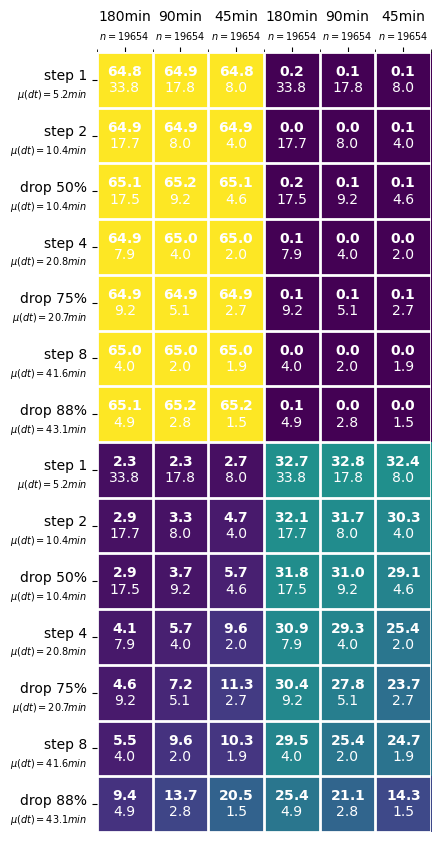

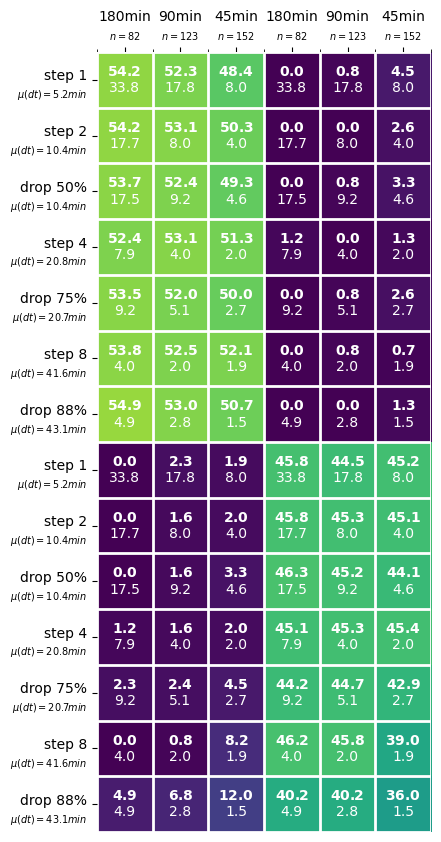

In [ ]:
n_tw, n_tp = len(grounding_timewindows_minutes), len(trajectory_parameters)
cum_cm_dim_x, cum_cm_dim_y = n_tp * 2, n_tw * 2
cum_cm_index = np.zeros((cum_cm_dim_x,cum_cm_dim_y))
cum_cm_section = np.zeros((cum_cm_dim_x,cum_cm_dim_y))
cum_mn_tw_nt = np.zeros((cum_cm_dim_x,cum_cm_dim_y))
cum_mn_dt = np.zeros(cum_cm_dim_x)
n_index = np.zeros((cum_cm_dim_x,cum_cm_dim_y))
n_section = np.zeros((cum_cm_dim_x,cum_cm_dim_y))

ylabels = []
for i_tp, tp_index in enumerate([0,1,4,2,5,3,6]):
  tp = trajectory_parameters[tp_index]
  cum_mn_dt[i_tp] = mean_dt[tp_index][0]/60
  cum_mn_dt[i_tp+n_tp] = mean_dt[tp_index][0]/60
  labeltype = (tp[0]==1) and not(tp[1]==0.00)
  ylabels += ["drop %d"%(100*tp[1])+"%"+"\n$_{\mu(dt)=%.1fmin}$"%(cum_mn_dt[i_tp]) if labeltype else "step %d\n$_{\mu(dt)=%.1fmin}$"%(tp[0],cum_mn_dt[i_tp])]

  #print("sample_interval_%d_rnd_drop_fraction_%.2f/"%tuple(tp))
  for i_gtw, gtw in enumerate(grounding_timewindows_minutes):
    grounding_displacement_timewindow_minutes = gtw
    grounding_displacement_caracteristic_distance = pos_stdev
    grounding_directional_timewindow_minutes = gtw
    trajectories_label = "sample_interval_%d_rnd_drop_fraction_%.2f"%tuple(tp)
    sum_cm_index = np.round(np.sum(cm_index[tp_index][i_gtw],axis=0)/np.sum(cm_index[tp_index][i_gtw])*100,1)
    sum_cm_section = np.round(np.sum(cm_section[tp_index][i_gtw],axis=0)/np.sum(cm_section[tp_index][i_gtw])*100,1)
    cum_cm_index[i_tp][i_gtw] = sum_cm_index[0][0]
    cum_cm_index[i_tp+n_tp][i_gtw] = sum_cm_index[1][0]
    cum_cm_index[i_tp][i_gtw+n_tw] = sum_cm_index[0][1]
    cum_cm_index[i_tp+n_tp][i_gtw+n_tw] = sum_cm_index[1][1]
    cum_cm_section[i_tp][i_gtw] = sum_cm_section[0][0]
    cum_cm_section[i_tp+n_tp][i_gtw] = sum_cm_section[1][0]
    cum_cm_section[i_tp][i_gtw+n_tw] = sum_cm_section[0][1]
    cum_cm_section[i_tp+n_tp][i_gtw+n_tw] = sum_cm_section[1][1]
    cum_mn_tw_nt[i_tp][i_gtw] = mean_timewindow_nt[tp_index][i_gtw]
    cum_mn_tw_nt[i_tp+n_tp][i_gtw] = mean_timewindow_nt[tp_index][i_gtw]
    cum_mn_tw_nt[i_tp][i_gtw+n_tw] = mean_timewindow_nt[tp_index][i_gtw]
    cum_mn_tw_nt[i_tp+n_tp][i_gtw+n_tw] = mean_timewindow_nt[tp_index][i_gtw]
    n_index[i_tp][i_gtw] = np.sum(cm_index[tp_index][i_gtw])
    n_index[i_tp+n_tp][i_gtw] = np.sum(cm_index[tp_index][i_gtw])
    n_index[i_tp][i_gtw+n_tw] = np.sum(cm_index[tp_index][i_gtw])
    n_index[i_tp+n_tp][i_gtw+n_tw] = np.sum(cm_index[tp_index][i_gtw])
    n_section[i_tp][i_gtw] = np.sum(cm_section[tp_index][i_gtw])
    n_section[i_tp+n_tp][i_gtw] = np.sum(cm_section[tp_index][i_gtw])
    n_section[i_tp][i_gtw+n_tw] = np.sum(cm_section[tp_index][i_gtw])
    n_section[i_tp+n_tp][i_gtw+n_tw] = np.sum(cm_section[tp_index][i_gtw])

#print(cum_cm_index)
#print(cum_cm_section)

# collective confusion mat per index
fig, ax = plt.subplots(figsize=(1.5*n_tw,1.5*n_tp))
im = ax.imshow(cum_cm_index, vmin=0, vmax=65)
xlabels_index = 2*["%dmin\n$_{n=%d}$"%(gtw,np.mean(n_index[:,i_gtw])) for i_gtw, gtw in enumerate(grounding_timewindows_minutes)]
ylabels_index = 2*ylabels
ax.xaxis.tick_top()
ax.set_xticks(np.arange(cum_cm_index.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(cum_cm_index.shape[0]+1)-.5, minor=True)
ax.set_xticks(range(len(xlabels_index)), labels=xlabels_index) #, rotation=90, ha="right", rotation_mode="anchor"
ax.set_yticks(range(len(ylabels_index)), labels=ylabels_index)
ax.spines[:].set_visible(False)

for i in range(cum_cm_index.shape[0]):
    for j in range(cum_cm_index.shape[1]):
        text = ax.text(j, i, "$\mathbf{%.1f}$\n%.1f"%(cum_cm_index[i,j],cum_mn_tw_nt[i,j]), ha="center", va="center", color="w")
        #$\mathbf{\underline{%.1f}}$\n$_{\mu(n)=}%.1f$\n$_{\mu(dt)=}%.1f_{min}$
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
fig.tight_layout()
plt.savefig("plot/collection_cm_per_index.png")
plt.show() if verbose else None

# collective confusion mat per section
fig, ax = plt.subplots(figsize=(1.5*n_tw,1.5*n_tp))
im = ax.imshow(cum_cm_section, vmin=0, vmax=65)
xlabels_section = 2*["%dmin\n$_{n=%d}$"%(gtw,np.mean(n_section[:,i_gtw])) for i_gtw, gtw in enumerate(grounding_timewindows_minutes)]
ylabels_section = 2*ylabels
ax.xaxis.tick_top()
ax.set_xticks(np.arange(cum_cm_section.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(cum_cm_section.shape[0]+1)-.5, minor=True)
ax.set_xticks(range(len(xlabels_section)), labels=xlabels_section) #, rotation=90, ha="right", rotation_mode="anchor"
ax.set_yticks(range(len(ylabels_section)), labels=ylabels_section)
ax.spines[:].set_visible(False)

for i in range(cum_cm_section.shape[0]):
    for j in range(cum_cm_section.shape[1]):
        text = ax.text(j, i, "$\mathbf{%.1f}$\n%.1f"%(cum_cm_section[i,j],cum_mn_tw_nt[i,j]), ha="center", va="center", color="w")
        #$\mathbf{\underline{%.1f}}$\n$_{\mu(n)=}%.1f$\n$_{\mu(dt)=}%.1f_{min}$
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
fig.tight_layout()
plt.savefig("plot/collection_cm_per_section.png")
plt.show() if verbose else None